In [1]:
import pandas as pd

df = pd.read_json("../data/ir-metadata-overview.jsonl", lines=True)
df.head(3)

,libs,runtime,repo,lexical,deep_neural_model,sparse_neural_model,dense_neural_model,single_stage_retrieval,team,run_id
0,"[Pandas, OpenAI, NumPy, scikit-learn, PyTerrier]",[],local-run (no public repository),True,False,False,False,True,Lexora,QwenTemporalIR
1,"[click, python-terrier, tirex-tracker, ir-data...","[30022 ms, 660643 ms, 14718 ms, 532536 ms, 128...",git@github.com:OpenWebSearch/LONGEVAL-26.git,True,True,False,False,False,OpenWebSearch,put-to-front
2,"[ir-datasets-longeval, pyterrier-dr, pyterrier]",[],https://github.com/clef-longeval/longeval-code,False,True,False,True,False,LongEval,baseline-qwen3-4b


In [2]:
# fix some issues with the data
df = df[~df["team"].isin(["LongEval", "my-team"])]
df = df.replace({"team": {"KumaranD": "Lexora"}})
df = df[df["run_id"] != "delete-me"]

In [3]:
# Number of teams
print(df["team"].unique())
len(df["team"].unique())

<ArrowStringArray>
[                     'Lexora',               'OpenWebSearch',
          'clef26-air-benders',               'Time4Citation',
            'clef26-tu-air-02',                        'GLHF',
 'tira_vm_clef26-nlp-hashiras',                'dense-fusion']
Length: 8, dtype: str


8

In [4]:
# Number of submissions

len(df["run_id"].unique())

20

In [5]:
# Teams with a repo on github:

print(df[["team", "repo"]].to_markdown())#.str.contains("github")]["team"].unique()

|    | team                        | repo                                                                                |
|---:|:----------------------------|:------------------------------------------------------------------------------------|
|  0 | Lexora                      | local-run (no public repository)                                                    |
|  1 | OpenWebSearch               | git@github.com:OpenWebSearch/LONGEVAL-26.git                                        |
|  3 | clef26-air-benders          | not-publicly-available                                                              |
|  4 | Time4Citation               | https://github.com/irgroup-classrooms/dis18-2025                                    |
|  5 | Lexora                      | local-run (no public repository)                                                    |
|  6 | Time4Citation               | https://github.com/irgroup-classrooms/dis18-2025                                    |
|  7 | Lexora   

|    | team                        | repo                                                                                |
|---:|:----------------------------|:------------------------------------------------------------------------------------|
|  0 | Lexora                      | local-run (no public repository)                                                    |
|  3 | clef26-air-benders          | not-publicly-available                                                              |
|  1 | OpenWebSearch               | git@github.com:OpenWebSearch/LONGEVAL-26.git                                        |
|  4 | Time4Citation               | https://github.com/irgroup-classrooms/dis18-2025                                    |
|  8 | clef26-tu-air-02            | https://github.com/TU-Wien-DS/longeval-task-1-longeval-task-1-methodology-1-group-2 |
| 13 | tira_vm_clef26-nlp-hashiras | https://github.com/rusenbb/bm25-or-die-trying                                       |
| 16 | dense-fusion                | https://github.com/Vico0306/longeval-sci/tree/main                                  |
|  9 | GLHF                        | https://github.com/WiJoWill/longeval2026task1                                       |

In [6]:
# Teams with a repo on bitbucket:

len(df[df["repo"].str.contains("bitbucket")]["team"].unique())

0

In [7]:
# Teams with public repo:
# df
#len(df[df["repo_is_public"]]["team"].unique())

In [8]:
# Teams that tracked respource consumptoin:

len(df[df["runtime"].astype(bool)]["team"].unique())

1

In [9]:
# Runs that tracked respource consumption:

len(df[df["runtime"].astype(bool)]["run_id"].unique())

4

In [10]:
team_to_libs = {}

lib_to_name = {"PyTerrier": "python-terrier", "pytorch": "torch", "sqlalchemy": "SQLAlchemy", "org.apache.lucene": "Lucene"}


for _, i in df.iterrows():
    if i["team"] not in team_to_libs:
        team_to_libs[i["team"]] = set()

    for lib in i["libs"]:
        team_to_libs[i["team"]].add(lib_to_name.get(lib, lib))

lib_counts = []

NON_LIBS = set(["Apache", "Python", "Java", "os"])

for v in team_to_libs.values():
    for k in v:
        if k in NON_LIBS:
            continue
        lib_counts.append({"lib": k})

lib_counts = pd.DataFrame(lib_counts)

In [19]:
lib_counts.value_counts().head(10)

lib                  
python-terrier           8
ir-datasets-longeval     4
numpy                    4
scikit-learn             3
tirex-tracker            3
torch                    3
pandas                   3
sentence-transformers    3
ir_datasets              3
tira                     2
Name: count, dtype: int64

In [18]:
df

,libs,runtime,repo,lexical,deep_neural_model,sparse_neural_model,dense_neural_model,single_stage_retrieval,team,run_id
0,"[Pandas, OpenAI, NumPy, scikit-learn, PyTerrier]",[],local-run (no public repository),True,False,False,False,True,Lexora,QwenTemporalIR
1,"[click, python-terrier, tirex-tracker, ir-data...","[30022 ms, 660643 ms, 14718 ms, 532536 ms, 128...",git@github.com:OpenWebSearch/LONGEVAL-26.git,True,True,False,False,False,OpenWebSearch,put-to-front
3,"[pandas, sentence-transformers, python-terrier...",[],not-publicly-available,True,False,False,False,True,clef26-air-benders,baseline-bm25-dense-rerank-secondversion
4,"[polars, ir_datasets, python-terrier, marimo, ...",[],https://github.com/irgroup-classrooms/dis18-2025,True,False,False,False,False,Time4Citation,binary-boost-09
5,[PyTerrier],[],local-run (no public repository),True,False,False,False,False,Lexora,temporal-fusion
6,"[polars, ir_datasets, python-terrier, marimo, ...",[],https://github.com/irgroup-classrooms/dis18-2025,True,False,False,False,False,Time4Citation,Log-boost-03
7,[PyTerrier],[],local-run (no public repository),True,False,False,False,False,Lexora,rm3-conservative
8,"[parso, fonttools, ir-datasets-longeval, pip, ...",[],https://github.com/TU-Wien-DS/longeval-task-1-...,True,True,False,False,True,clef26-tu-air-02,ce-reranked
9,"[python, python-terrier, numpy, ir-datasets-lo...",[],https://github.com/WiJoWill/longeval2026task1,True,False,False,False,False,GLHF,bm25-ft-router
10,"[python, python-terrier, numpy, ir-datasets-lo...",[],https://github.com/WiJoWill/longeval2026task1,True,False,False,False,False,GLHF,custom-lexicalft-tc


In [12]:
paradigms = []
for i, v in [("lexical", "Lexical"), ("deep_neural_model", "Deep Neural"), ("sparse_neural_model", "Sparse"), ("dense_neural_model", "Dense Neural"), ("single_stage_retrieval", "Single Stage")]:
    paradigms.append({"Paradigm": v, "Runs": len([j for j in df[i] if j]) , "Used?": "Yes"})
    paradigms.append({"Paradigm": v, "Runs": len([j for j in df[i] if not j]) , "Used?": "No"})
paradigms = pd.DataFrame(paradigms)
paradigms

,Paradigm,Runs,Used?
0,Lexical,20,Yes
1,Lexical,0,No
2,Deep Neural,3,Yes
3,Deep Neural,17,No
4,Sparse,0,Yes
5,Sparse,20,No
6,Dense Neural,1,Yes
7,Dense Neural,19,No
8,Single Stage,5,Yes
9,Single Stage,15,No


<Axes: xlabel='Paradigm', ylabel='Runs'>

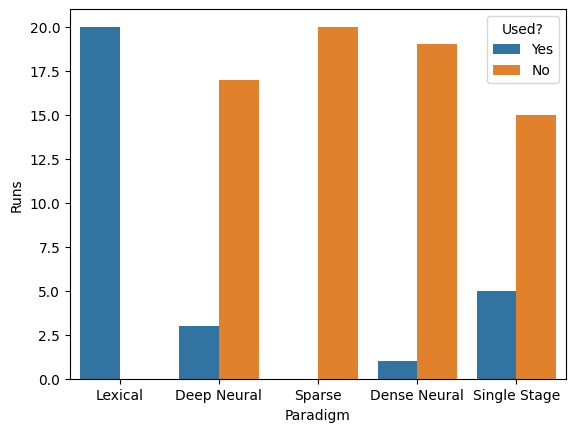

In [13]:
import seaborn as sns

sns.barplot(paradigms, x="Paradigm", y="Runs", hue="Used?")

In [15]:
df

,libs,runtime,repo,lexical,deep_neural_model,sparse_neural_model,dense_neural_model,single_stage_retrieval,team,run_id
0,"[Pandas, OpenAI, NumPy, scikit-learn, PyTerrier]",[],local-run (no public repository),True,False,False,False,True,Lexora,QwenTemporalIR
1,"[click, python-terrier, tirex-tracker, ir-data...","[30022 ms, 660643 ms, 14718 ms, 532536 ms, 128...",git@github.com:OpenWebSearch/LONGEVAL-26.git,True,True,False,False,False,OpenWebSearch,put-to-front
3,"[pandas, sentence-transformers, python-terrier...",[],not-publicly-available,True,False,False,False,True,clef26-air-benders,baseline-bm25-dense-rerank-secondversion
4,"[polars, ir_datasets, python-terrier, marimo, ...",[],https://github.com/irgroup-classrooms/dis18-2025,True,False,False,False,False,Time4Citation,binary-boost-09
5,[PyTerrier],[],local-run (no public repository),True,False,False,False,False,Lexora,temporal-fusion
6,"[polars, ir_datasets, python-terrier, marimo, ...",[],https://github.com/irgroup-classrooms/dis18-2025,True,False,False,False,False,Time4Citation,Log-boost-03
7,[PyTerrier],[],local-run (no public repository),True,False,False,False,False,Lexora,rm3-conservative
8,"[parso, fonttools, ir-datasets-longeval, pip, ...",[],https://github.com/TU-Wien-DS/longeval-task-1-...,True,True,False,False,True,clef26-tu-air-02,ce-reranked
9,"[python, python-terrier, numpy, ir-datasets-lo...",[],https://github.com/WiJoWill/longeval2026task1,True,False,False,False,False,GLHF,bm25-ft-router
10,"[python, python-terrier, numpy, ir-datasets-lo...",[],https://github.com/WiJoWill/longeval2026task1,True,False,False,False,False,GLHF,custom-lexicalft-tc
